# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
)

In [5]:
data = pd.read_csv("INNHotelsGroup.csv")
df = data.copy()
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Data Overview

- Observations
- Sanity checks

In [6]:
print("There are", df.shape[0], "rows and", df.shape[1], "columns in the data.")

There are 36275 rows and 19 columns in the data.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [8]:
# Checking for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Checking for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

Number of duplicate rows: 0

Missing values in each column:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [10]:
df.describe(include="object").T

,count,unique,top,freq
Booking_ID,36275,36275,INN36275,1
type_of_meal_plan,36275,4,Meal Plan 1,27835
room_type_reserved,36275,7,Room_Type 1,28130
market_segment_type,36275,5,Online,23214
booking_status,36275,2,Not_Canceled,24390


In [11]:
df.nunique()

,0
Booking_ID,36275
no_of_adults,5
no_of_children,6
no_of_weekend_nights,8
no_of_week_nights,18
type_of_meal_plan,4
required_car_parking_space,2
room_type_reserved,7
lead_time,352
arrival_year,2


**Observations from the summary statistics:**

* `Booking_ID` is different for every booking, so it does not provide any useful information for predicting cancellations. Therefore, I will drop this column before building the models.

* `no_of_adults` ranges from 0 to 4, while `no_of_children` ranges from 0 to 10. Most bookings have a reasonable number of guests, but some bookings have a very high number of children, which may need further investigation.

* `lead_time` ranges from 0 to 443 days. This means that some customers book their rooms on the same day, while others book many months in advance. The variable may be right-skewed, so I will check its distribution using a plot.

* `avg_price_per_room` ranges from 0 to 540. The value of 0 looks unusual because a room normally has some price. I will investigate these observations further during EDA.

* `arrival_year` contains only two years, 2017 and 2018.

* `repeated_guest` and `required_car_parking_space` are binary variables, meaning they contain 0/1 values.


In [12]:
print("Bookings with 0 adults:", (df["no_of_adults"] == 0).sum())
print("Bookings with 0 adults AND 0 children:", ((df["no_of_adults"] == 0) & (df["no_of_children"] == 0)).sum())
df[df["no_of_children"].isin([9, 10])]

Bookings with 0 adults: 139
Bookings with 0 adults AND 0 children: 0


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
6338,INN06339,2,10,0,2,Meal Plan 1,0,Room_Type 4,37,2018,1,12,Online,0,0,0,84.45,1,Not_Canceled
10041,INN10042,1,9,2,1,Meal Plan 1,0,Room_Type 1,11,2017,10,11,Corporate,0,0,0,95.00,0,Not_Canceled
10061,INN10062,2,9,2,5,Meal Plan 1,0,Room_Type 2,8,2017,8,13,Online,0,0,0,76.50,1,Canceled


**Observation:**

There are 139 bookings where the number of adults is 0, but all of these bookings have at least one child. So, these do not necessarily mean that the bookings are empty. They could be bookings made for groups where only children are included in the booking details.

There are also 3 bookings with 9–10 children, which is quite high compared to the other bookings. However, these are only 3 records out of 36,275 records. Since they are very few and we cannot say that they are incorrect data, I have decided to keep them in the dataset instead of removing them as outliers.


In [13]:
print("Bookings with avg_price_per_room = 0:", (df["avg_price_per_room"] == 0).sum())
df[df["avg_price_per_room"] == 0]["market_segment_type"].value_counts()

Bookings with avg_price_per_room = 0: 545


,count
market_segment_type,
Complementary,354
Online,191


**Observation:**

There are 545 bookings where the room price is 0. Out of these, 354 bookings belong to the **Complementary** market segment. This suggests that these rooms were provided free of cost, so the value of 0 is likely to be valid and not a data error.

The remaining 191 bookings belong to the **Online** market segment. These could be related to discounted or reward-based bookings. Since there is a valid reason for the zero prices, I have decided not to remove or modify these records.


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

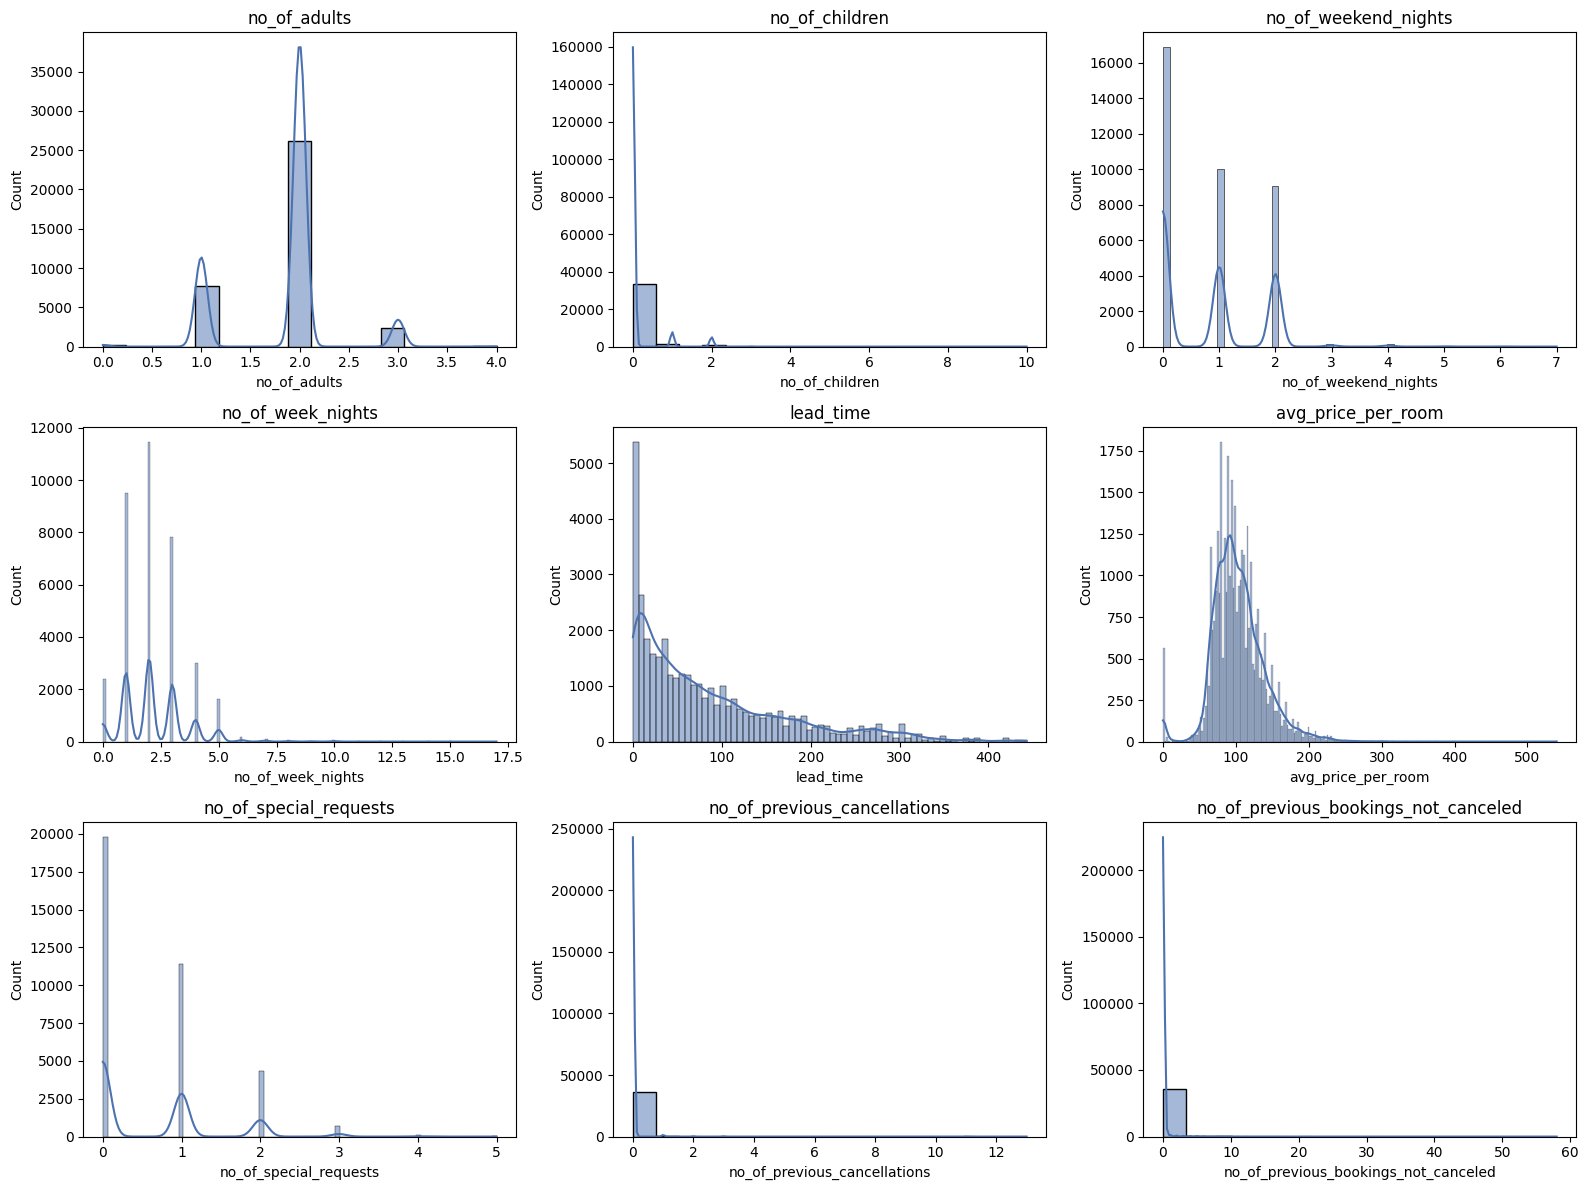

In [14]:
num_cols = [
    "no_of_adults", "no_of_children", "no_of_weekend_nights", "no_of_week_nights",
    "lead_time", "avg_price_per_room", "no_of_special_requests",
    "no_of_previous_cancellations", "no_of_previous_bookings_not_canceled"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


**Observations:**

* Most of the bookings have **2 adults and no children**. Bookings with a larger number of guests are comparatively less common.

* `no_of_weekend_nights` and `no_of_week_nights` are both right-skewed. This shows that most customers prefer relatively short stays, while only a few bookings are for longer stays.

* `lead_time` is also highly right-skewed. Many customers make their bookings close to the arrival date, while some customers book much earlier, with the maximum lead time going up to 443 days.

* `avg_price_per_room` is mostly concentrated around **€100**. There are also some bookings with a price of 0, which we saw earlier are mainly related to complementary bookings.

* `no_of_previous_cancellations` and `no_of_previous_bookings_not_canceled` are highly right-skewed. Most customers do not have any previous booking history with the hotel, while only a small number of customers have multiple previous bookings.

* `no_of_special_requests` is also right-skewed. Most customers make **0 or 1 special request**, and only a few customers make a larger number of requests.




### Univariate analysis - categorical variables

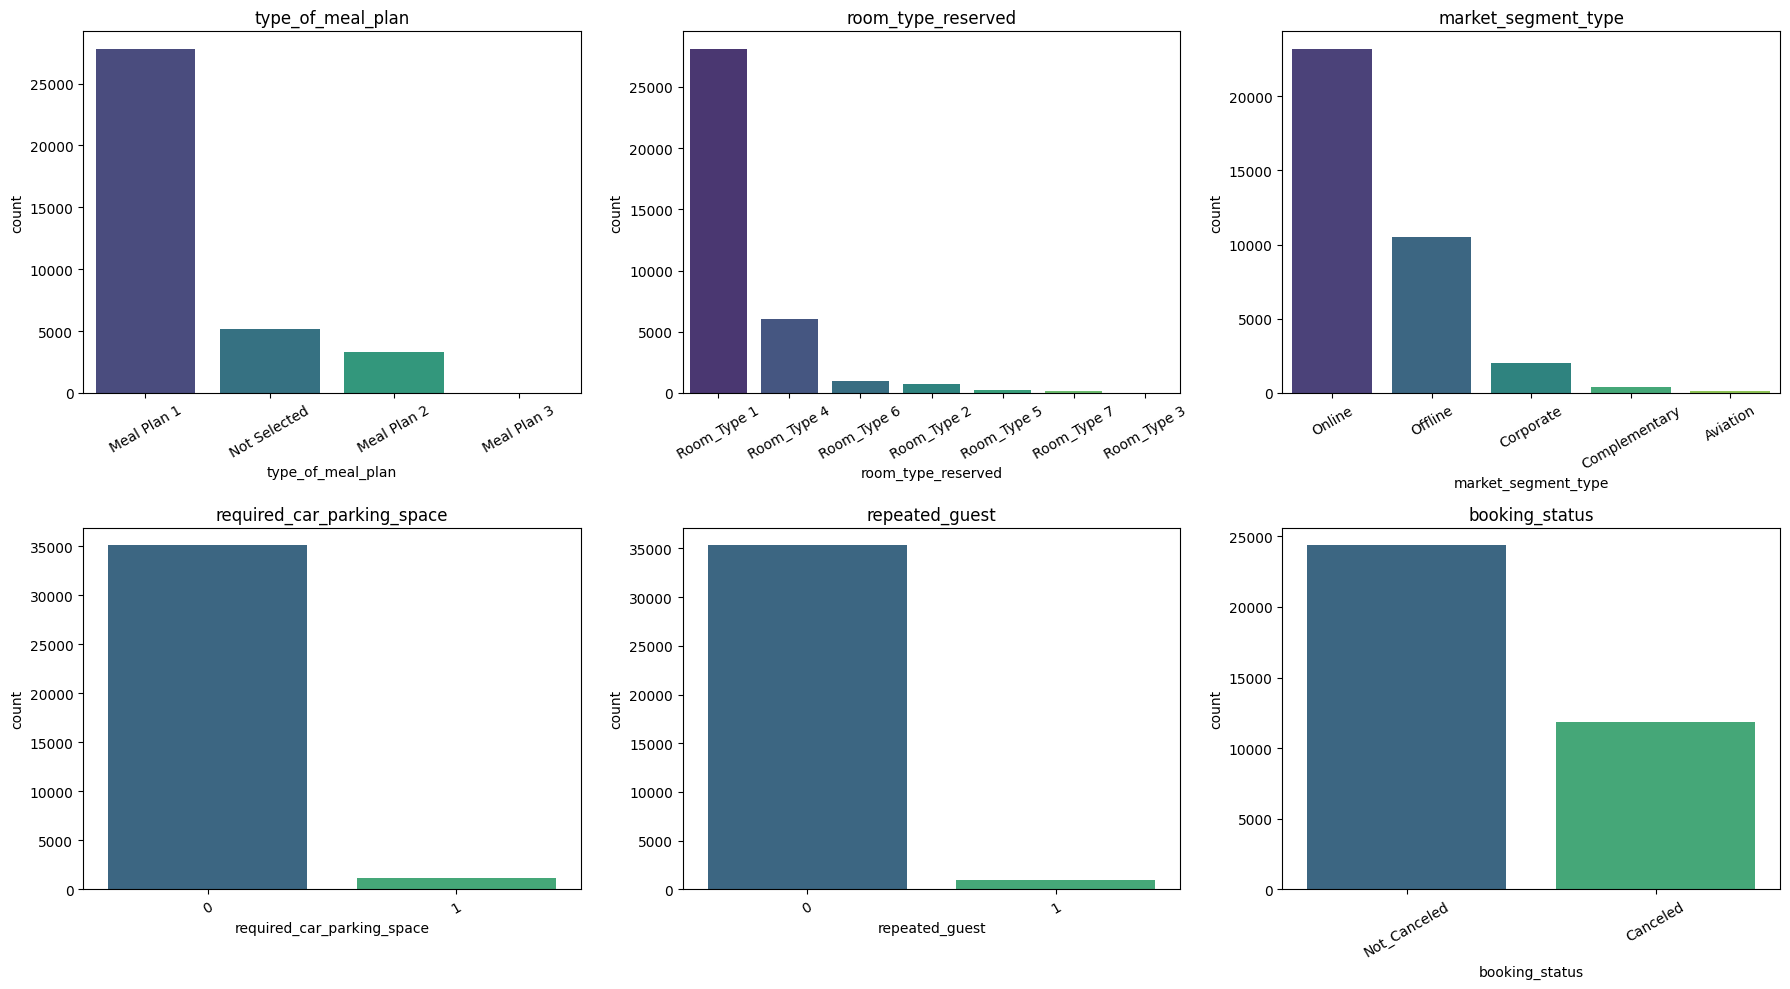

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_plots = [
    ("type_of_meal_plan", None),
    ("room_type_reserved", None),
    ("market_segment_type", None),
    ("required_car_parking_space", None),
    ("repeated_guest", None),
    ("booking_status", None),
]
for i, (col, _) in enumerate(cat_plots):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observations:**

* **Meal Plan 1** is the most commonly selected meal plan by customers. On the other hand, **Meal Plan 3** is very rarely selected, with only 5 bookings.

* **Room Type 1** is the most popular room type and accounts for around **78% of the bookings**. The other room types have much fewer bookings.

* The **Online** market segment has the highest number of bookings, followed by **Offline** and **Corporate**. **Aviation** and **Complementary** have comparatively fewer bookings.

* Most guests do **not request a parking space**. Also, most of the guests are **not repeat guests**, which suggests that a large number of bookings come from new customers.

* Around **one-third of the bookings are canceled**. This is a significant number of cancellations and shows why it is important for the hotel to understand the factors that are related to booking cancellations.


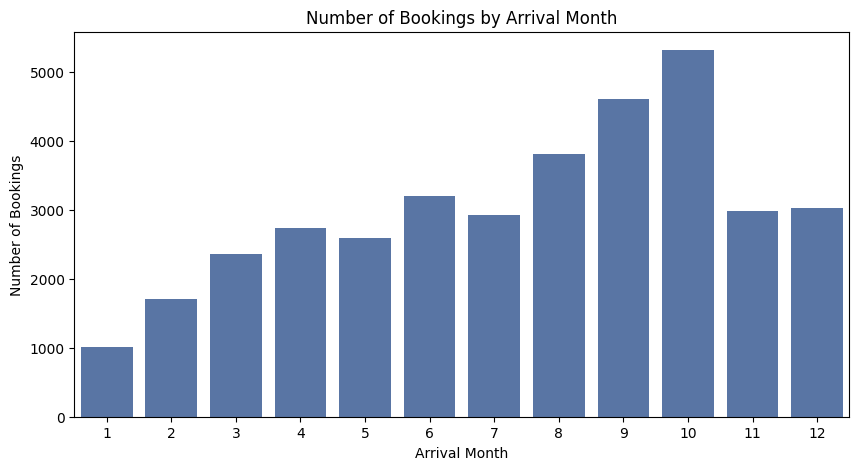

,count
arrival_month,
1,1014
2,1704
3,2358
4,2736
5,2598
6,3203
7,2920
8,3813
9,4611


In [16]:
# Q1: What are the busiest months in the hotel (by arrival)?
plt.figure(figsize=(10, 5))
month_order = sorted(df["arrival_month"].unique())
sns.countplot(x="arrival_month", data=df, order=month_order, color="#4C72B0")
plt.title("Number of Bookings by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.show()

df["arrival_month"].value_counts().sort_index()

 **October** is the busiest month by a clear margin (5,317 bookings), followed by September and August, a strong autumn peak, likely tied to Portugal's tourist season. January is by far the quietest month.

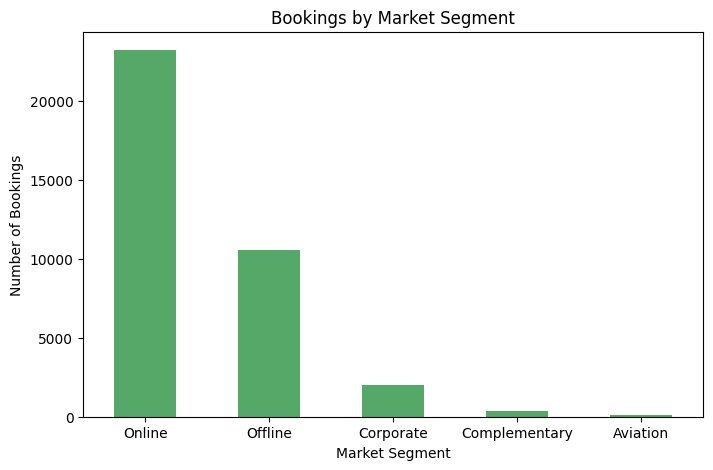

,count
market_segment_type,
Online,64.0
Offline,29.0
Corporate,5.6
Complementary,1.1
Aviation,0.3


In [17]:
# Q2: Which market segment do most guests come from?
plt.figure(figsize=(8, 5))
seg_counts = df["market_segment_type"].value_counts()
seg_counts.plot(kind="bar", color="#55A868")
plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()

(seg_counts / len(df) * 100).round(1)

 The **Online** channel brings in the most guests by far(64% of all bookings) followed by Offline travel-agent/walk-in bookings (29%). Corporate, Aviation and Complementary segments together make up under 7% of bookings.

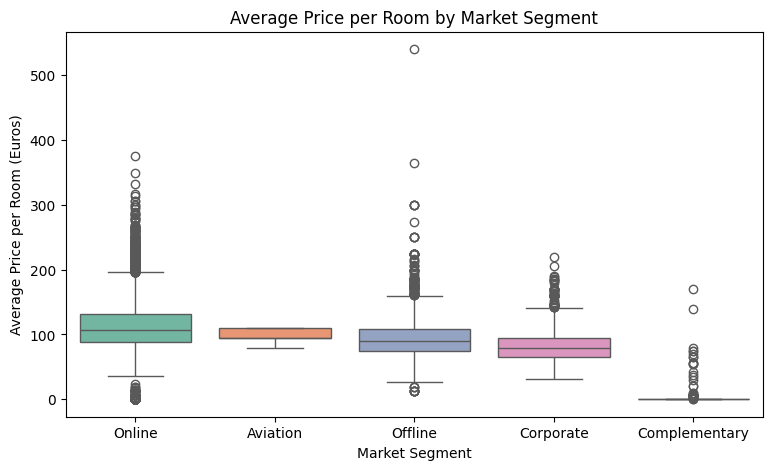

,mean,50%,min,max
market_segment_type,,,,
Aviation,100.704000,95.0,79.0,110.0
Complementary,3.141765,0.0,0.0,170.0
Corporate,82.911740,79.0,31.0,220.0
Offline,91.632679,90.0,12.0,540.0
Online,112.256855,107.1,0.0,375.5


In [18]:
# Q3: How do room prices differ across market segments?
plt.figure(figsize=(9, 5))
order = df.groupby("market_segment_type")["avg_price_per_room"].median().sort_values(ascending=False).index
sns.boxplot(x="market_segment_type", y="avg_price_per_room", data=df, order=order, palette="Set2")
plt.title("Average Price per Room by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Average Price per Room (Euros)")
plt.show()

df.groupby("market_segment_type")["avg_price_per_room"].describe()[["mean", "50%", "min", "max"]]


The **Online** segment has the highest average room price, at around **€112** per room. It is followed by **Aviation** at around **€101** and **Offline** at around **€92**.

The average price for **Corporate** bookings is lower, at around **€83**, which may be because corporate customers get special or negotiated rates.

The **Complementary** segment has an average price close to **€0**, which is expected because these bookings are provided free of charge.


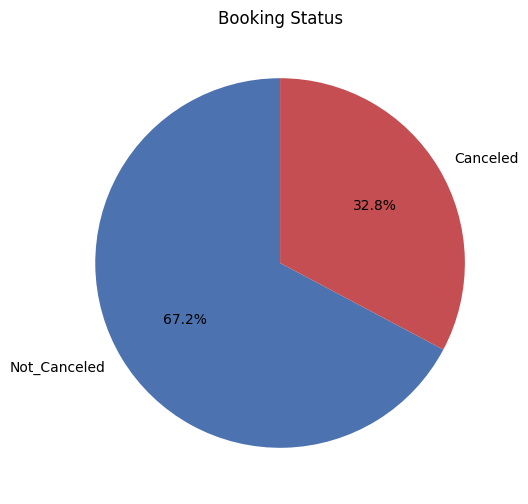

,proportion
booking_status,
Not_Canceled,67.24
Canceled,32.76


In [19]:
# Q4: What percentage of bookings are canceled?
cancel_pct = df["booking_status"].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
plt.pie(cancel_pct, labels=cancel_pct.index, autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"], startangle=90)
plt.title("Booking Status")
plt.show()

cancel_pct.round(2)

**32.76%** of all bookings are eventually canceled, :nearly 1 in 3 bookings. This confirms cancellations are a large, material problem for the business, not a marginal one.

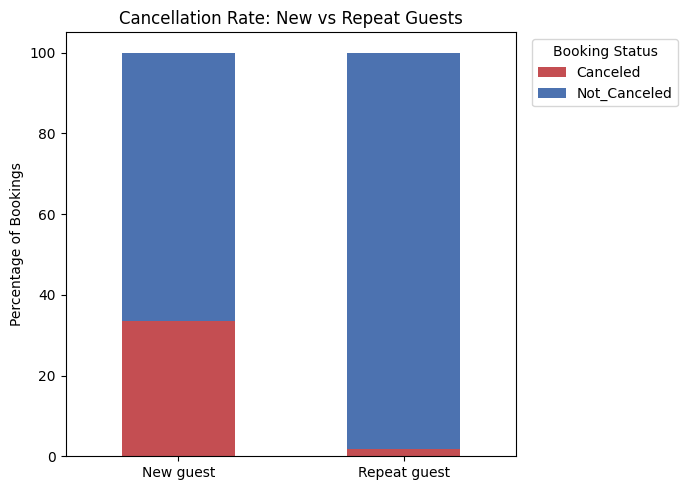

booking_status,Canceled,Not_Canceled
New guest,33.58,66.42
Repeat guest,1.72,98.28


In [20]:
# Q5: What percentage of repeating guests cancel?
repeat_cancel = pd.crosstab(df["repeated_guest"], df["booking_status"], normalize="index") * 100
repeat_cancel.index = ["New guest", "Repeat guest"]
repeat_cancel.plot(kind="bar", stacked=True, figsize=(7, 5), color=["#C44E52", "#4C72B0"])
plt.title("Cancellation Rate: New vs Repeat Guests")
plt.ylabel("Percentage of Bookings")
plt.xticks(rotation=0)
plt.legend(title="Booking Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

repeat_cancel.round(2)

The cancellation rate for repeat guests is only 1.72%, whereas it is 33.58% for new guests. This shows that repeat guests are much less likely to cancel their bookings compared to first-time guests.

Therefore, being a repeat guest appears to be an important factor associated with lower cancellation rates.

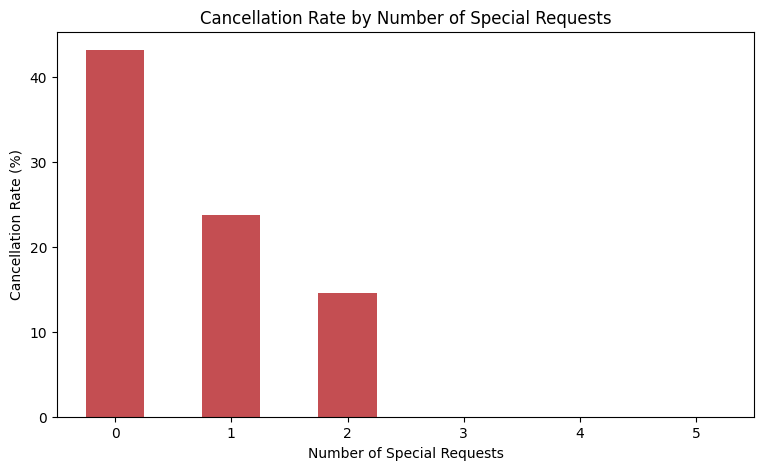

booking_status,Canceled,Not_Canceled
no_of_special_requests,,
0,43.21,56.79
1,23.77,76.23
2,14.60,85.40
3,0.00,100.00
4,0.00,100.00
5,0.00,100.00


In [23]:
# Q6: Do special requests affect cancellation?
req_cancel = pd.crosstab(df["no_of_special_requests"], df["booking_status"], normalize="index") * 100
plt.figure(figsize=(9, 5))
req_cancel["Canceled"].plot(kind="bar", color="#C44E52")
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

req_cancel.round(2)

 Cancellation rate drops sharply as the number of special requests increases from **43.2%** with zero requests to **23.8%** with one request, **14.6%** with two, and **0%** for guests with three or more requests. Guests who take the time to make special requests appear far more invested in their stay and are much less likely to cancel.

###  Bivariate analysis




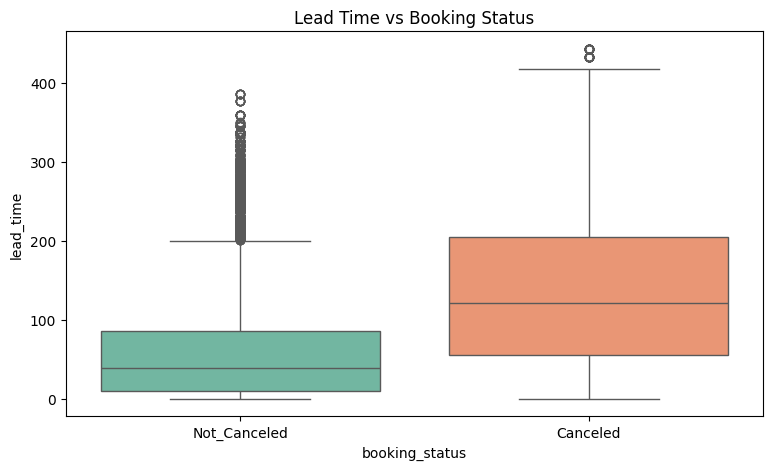

,lead_time
booking_status,
Canceled,122.0
Not_Canceled,39.0


In [24]:
# Lead time vs cancellation
plt.figure(figsize=(9, 5))
sns.boxplot(x="booking_status", y="lead_time", data=df, palette="Set2")
plt.title("Lead Time vs Booking Status")
plt.show()

df.groupby("booking_status")["lead_time"].median()

**Observation:** Canceled bookings have a much longer median lead time 113 days than bookings that were kept 43 days. The longer a booking is made in advance, the more time there is for a guest's plans to change.

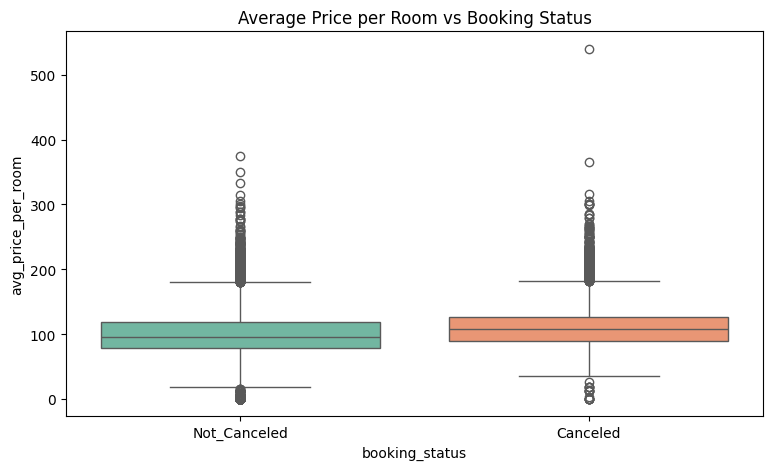

,avg_price_per_room
booking_status,
Canceled,108.0
Not_Canceled,95.0


In [25]:
# Average room price vs cancellation
plt.figure(figsize=(9, 5))
sns.boxplot(x="booking_status", y="avg_price_per_room", data=df, palette="Set2")
plt.title("Average Price per Room vs Booking Status")
plt.show()

df.groupby("booking_status")["avg_price_per_room"].median()

**Observation:**

The average room price for canceled bookings is slightly higher than that of bookings that were not canceled. This suggests that bookings with higher room prices may have a slightly higher chance of being canceled. However, the difference is not very large, so other factors may also be responsible for cancellations.




In [26]:
# Car parking requirement vs cancellation
park_cancel = pd.crosstab(df["required_car_parking_space"], df["booking_status"], normalize="index") * 100
park_cancel.round(2)

booking_status,Canceled,Not_Canceled
required_car_parking_space,,
0,33.49,66.51
1,10.14,89.86


**Observation:** Guests who reserve a parking space cancel only **10.1%** of the time, versus **33.5%** for those who don't.

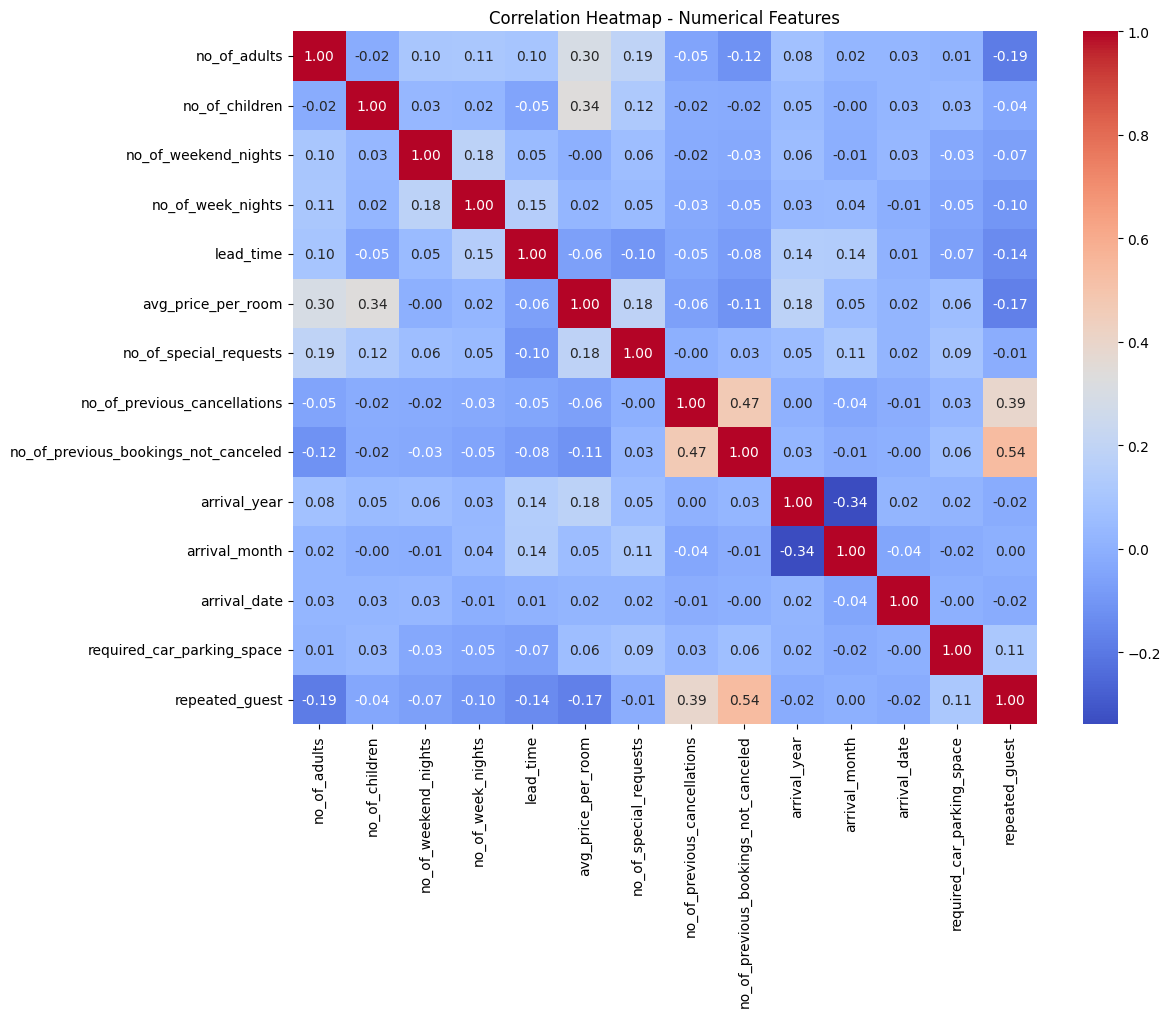

In [27]:
# Correlation heatmap of numerical features
plt.figure(figsize=(12, 9))
corr_cols = num_cols + ["arrival_year", "arrival_month", "arrival_date", "required_car_parking_space", "repeated_guest"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

**Observation:** No pair of numerical predictors is strongly correlated (all |correlation| well under 0.5), so we do not expect severe multicollinearity among the continuous variables going into the model. This is formally re-checked with VIF after encoding.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [28]:
# Dropping the unique identifier column
df_model = df.drop(columns=["Booking_ID"])

# Encoding the target: 1 = Canceled, 0 = Not_Canceled
df_model["booking_status"] = df_model["booking_status"].apply(lambda x: 1 if x == "Canceled" else 0)

df_model["booking_status"].value_counts(normalize=True)

,proportion
booking_status,
0,0.672364
1,0.327636


In [29]:
# Separating features and target
X = df_model.drop(columns=["booking_status"])
y = df_model["booking_status"]

# One-hot encoding the categorical columns
X = pd.get_dummies(
    X,
    columns=["type_of_meal_plan", "room_type_reserved", "market_segment_type"],
    drop_first=True,
)
X = X.astype(float)

print("Shape of X after encoding:", X.shape)
X.head()

Shape of X after encoding: (36275, 27)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2.0,0.0,1.0,2.0,0.0,224.0,2017.0,10.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,0.0,2.0,3.0,0.0,5.0,2018.0,11.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,2.0,1.0,0.0,1.0,2018.0,2.0,28.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2.0,0.0,0.0,2.0,0.0,211.0,2018.0,5.0,20.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.0,0.0,1.0,1.0,0.0,48.0,2018.0,4.0,11.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [30]:
# Splitting the data into train and test sets (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nCancellation rate in train:", round(y_train.mean(), 4))
print("Cancellation rate in test: ", round(y_test.mean(), 4))

X_train: (25392, 27)  X_test: (10883, 27)

Cancellation rate in train: 0.3276
Cancellation rate in test:  0.3277


**Observation:** The stratified split preserves the ~32.8% cancellation rate in both the train and test sets, so model performance on the test set should be a fair reflection of real world performance.

## EDA

- It is a good idea to explore the data once again after manipulating it.

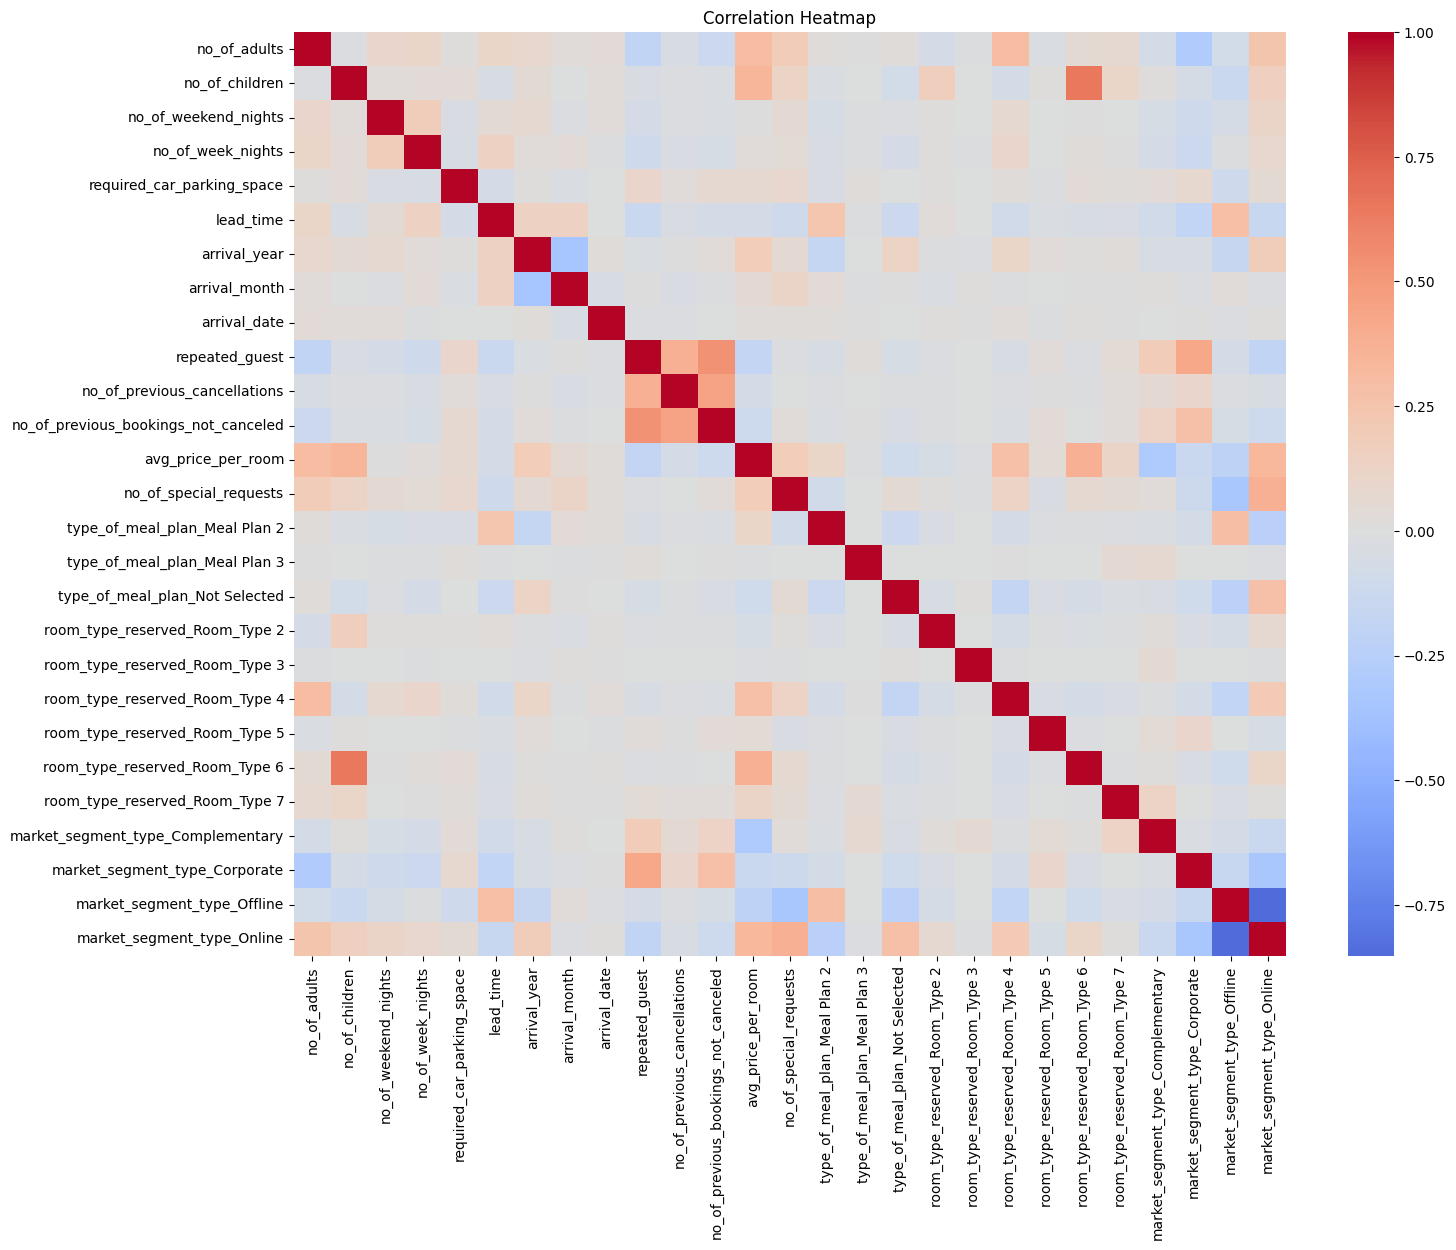

In [32]:
# Correlation heatmap of the encoded training features
plt.figure(figsize=(16, 12))
sns.heatmap(X_train.corr(), cmap="coolwarm", center=0, cbar=True)
plt.title("Correlation Heatmap")
plt.show()

**Observation:**

The dummy variables belonging to the same categorical variable show some negative correlation with each other. This is expected because only one category can be present for a booking.

Apart from these variables, there are no major correlations between the other independent variables. This suggests that multicollinearity may not be a major problem in the dataset. I will confirm this using **VIF (Variance Inflation Factor)** in the next step.


## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [33]:
def compute_vif(X_data):
    """Returns a VIF table for the given feature set (adds its own intercept internally)."""
    X_const = sm.add_constant(X_data)
    vif = pd.DataFrame()
    vif["Feature"] = X_const.columns
    vif["VIF"] = [
        variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])
    ]
    return vif[vif["Feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

vif_table = compute_vif(X_train)
vif_table

,Feature,VIF
0,market_segment_type_Online,69.471832
1,market_segment_type_Offline,62.513007
2,market_segment_type_Corporate,16.634417
3,market_segment_type_Complementary,4.350047
4,avg_price_per_room,2.032631
5,no_of_children,2.007213
6,room_type_reserved_Room_Type 6,1.990106
7,repeated_guest,1.750194
8,no_of_previous_bookings_not_canceled,1.570863
9,arrival_year,1.433261


**Observation:**

Most of the numerical variables such as room price, lead time, number of nights, previous bookings, and special requests have a **VIF below 5**. This indicates that there is no major multicollinearity problem among these variables.

Some of the dummy variables for `market_segment_type` have higher VIF values. This is mainly because these dummy variables are related to the same categorical variable and some market segments have much more bookings than others.

Therefore, I will not remove these variables only because of their VIF values. I will also look at the **p-values and model results** to decide which variables are useful for the Logistic Regression model.


## Building a Logistic Regression model

In [34]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def backward_elimination_logit(X_data, y_data, p_value_threshold=0.05):
    """Fits a statsmodels Logit model, iteratively dropping the least-significant
    feature until every remaining feature has a p-value below the threshold."""
    X_const = sm.add_constant(X_data)
    cols = list(X_const.columns)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore")
        while True:
            fitted_model = sm.Logit(y_data, X_const[cols]).fit(disp=0, maxiter=1000)
            p_values = fitted_model.pvalues.drop("const")
            worst_p = p_values.max()
            if worst_p > p_value_threshold:
                cols.remove(p_values.idxmax())
            else:
                break
    return fitted_model, cols

logit_model, logit_cols = backward_elimination_logit(X_train, y_train)
print("Number of features retained (excluding intercept):", len(logit_cols) - 1)
logit_model.summary()

Number of features retained (excluding intercept): 19


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25372
Method:                           MLE   Df Model:                           19
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                  0.3312
Time:                        12:39:34   Log-Likelihood:                -10741.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -869.8889    120.911     -7.194      0.000   -1106.870    -632.908
no_of_weekend_nights               0.1498      0.020      7.568      0.000       0.111       0.189
no_of_week_nights                  0.0362      0.012      2.953      0.003       0.012       0.060
required_car_parking_space        -1.6148      0.137    -11.780      0.000      -1.883      -1.346
lead_time                          0.0159      0.000     59.908      0.000       0.015       0.016
arrival_year                       0.4298      0.060      7.172      0.000       0.312       0.547
arrival_month                     -0.0492      0.006     -7.595      0.000      -0.062      -0.036
repeated_guest                    -3.0747      0.597     -5.152      0.000      -4.244      -1.905
no_of_previous_cancellations       0.2892      0.078      3.722      0.000       0.137       0.441
avg_price_per_room                 0.0190      0.001     26.645      0.000       0.018       0.020
no_of_special_requests            -1.4855      0.030    -49.272      0.000      -1.545      -1.426
type_of_meal_plan_Meal Plan 2      0.1669      0.067      2.492      0.013       0.036       0.298
type_of_meal_plan_Not Selected     0.2098      0.053      3.974      0.000       0.106       0.313
room_type_reserved_Room_Type 2    -0.3734      0.129     -2.891      0.004      -0.627      -0.120
room_type_reserved_Room_Type 4    -0.2678      0.052     -5.189      0.000      -0.369      -0.167
room_type_reserved_Room_Type 5    -0.6879      0.214     -3.211      0.001      -1.108      -0.268
room_type_reserved_Room_Type 6    -0.7419      0.120     -6.186      0.000      -0.977      -0.507
room_type_reserved_Room_Type 7    -1.3150      0.292     -4.504      0.000      -1.887      -0.743
market_segment_type_Corporate     -0.8710      0.103     -8.445      0.000      -1.073      -0.669
market_segment_type_Offline       -1.7725      0.052    -34.288      0.000      -1.874      -1.671
==================================================================================================
"""

**Observation:**

After performing backward elimination, the number of predictors was reduced from **26 to 19 significant predictors**, along with the intercept.

The variables `no_of_adults`, `no_of_children`, `arrival_date`, `no_of_previous_bookings_not_canceled`, `type_of_meal_plan_Meal Plan 3`, `room_type_reserved_Room_Type 3`, `market_segment_type_Complementary`, and `market_segment_type_Online` were removed because their p-values were not statistically significant in the model.

Some of these categories, such as **Meal Plan 3** and **Room Type 3**, also have very few bookings, which may be one reason why their effect is not significant.

The model has a **Pseudo R-squared of around 0.33**, which indicates that the model is able to explain a reasonable amount of variation in booking cancellations.


In [35]:
# Converting coefficients to odds ratios for easier business interpretation
odds_ratio = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Odds Ratio": np.exp(logit_model.params),
    "P-value": logit_model.pvalues,
})
odds_ratio = odds_ratio.drop("const").sort_values("Odds Ratio", ascending=False)
odds_ratio

,Coefficient,Odds Ratio,P-value
arrival_year,0.429767,1.536900,7.392436e-13
no_of_previous_cancellations,0.289186,1.335340,1.976646e-04
type_of_meal_plan_Not Selected,0.209845,1.233487,7.068441e-05
type_of_meal_plan_Meal Plan 2,0.166866,1.181596,1.269487e-02
no_of_weekend_nights,0.149823,1.161628,3.782270e-14
no_of_week_nights,0.036194,1.036857,3.144172e-03
avg_price_per_room,0.019044,1.019227,2.046459e-156
lead_time,0.015888,1.016014,0.000000e+00
arrival_month,-0.049165,0.952024,3.076688e-14
room_type_reserved_Room_Type 4,-0.267837,0.765033,2.111277e-07




An odds ratio greater than 1 means that the variable is associated with higher odds of cancellation, while an odds ratio less than 1 means lower odds of cancellation, keeping the other variables constant.

**Factors associated with higher cancellation odds:**

* `arrival_year`: Bookings in 2018 have around **54% higher odds of cancellation** compared to 2017.

* `no_of_previous_cancellations`: For every previous cancellation, the odds of canceling again increase by around **34%**.

* `type_of_meal_plan_Not Selected`: Customers who do not select a meal plan have around **23% higher odds of cancellation** compared to the reference meal plan.

* `lead_time`: For every additional day between booking and arrival, the odds of cancellation increase by around **1.6%**. Therefore, bookings made much earlier have a higher chance of cancellation.

* `avg_price_per_room`: For every €1 increase in room price, the odds of cancellation increase by around **1.9%**. This becomes roughly a **21% increase for a €10 increase** in room price.

**Factors associated with lower cancellation odds:**

* `repeated_guest`: Repeat guests have around **95% lower odds of cancellation** compared to new guests. This is also consistent with what we observed during EDA.

* `market_segment_type_Offline`: Offline bookings have around **83% lower odds of cancellation** compared to the Aviation segment, after keeping the other variables constant.

* `no_of_special_requests`: Each additional special request is associated with around **77% lower odds of cancellation**.

* `required_car_parking_space`: Guests who request a parking space have around **80% lower odds of cancellation**.

* Several room types, including **Room Type 2, 4, 5, 6 and 7**, also show lower cancellation odds compared to the reference **Room Type 1**.

Overall, the results show that factors such as **lead time, previous cancellations, room price and guest type** are related to the likelihood of cancellation. Repeat guests and guests who make special requests have much lower cancellation odds.


## Model performance evaluation

In [36]:
def get_metrics(y_true, y_pred, model_name="", dataset=""):
    return {
        "Model": model_name,
        "Data": dataset,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Canceled", "Canceled"],
                yticklabels=["Not Canceled", "Canceled"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

results = []

In [37]:
# Predicted probabilities on train and test
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test, has_constant="add")

logit_proba_train = logit_model.predict(X_train_const[logit_cols])
logit_proba_test = logit_model.predict(X_test_const[logit_cols])

# Classification at the default 0.5 threshold
logit_pred_train_05 = (logit_proba_train >= 0.5).astype(int)
logit_pred_test_05 = (logit_proba_test >= 0.5).astype(int)

results.append(get_metrics(y_train, logit_pred_train_05, "Logistic Regression (0.5 threshold)", "Train"))
results.append(get_metrics(y_test, logit_pred_test_05, "Logistic Regression (0.5 threshold)", "Test"))

pd.DataFrame(results)

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,0.806593,0.632528,0.739460,0.681827
1,Logistic Regression (0.5 threshold),Test,0.802720,0.626192,0.732852,0.675336


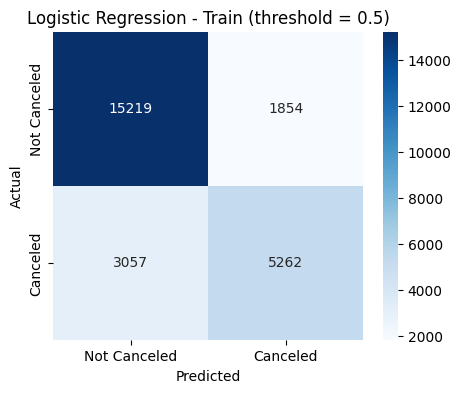

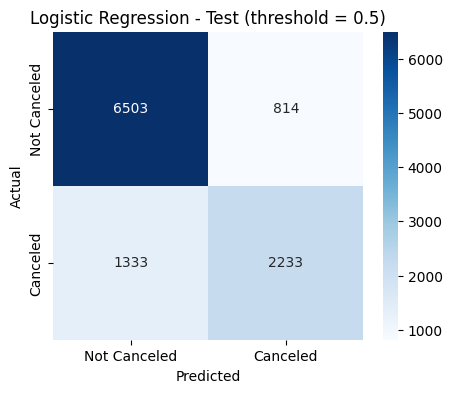

In [38]:
plot_confusion_matrix(y_train, logit_pred_train_05, "Logistic Regression - Train (threshold = 0.5)")
plot_confusion_matrix(y_test, logit_pred_test_05, "Logistic Regression - Test (threshold = 0.5)")

**Observation:**

At the default threshold of **0.5**, the Logistic Regression model has an accuracy of around **80%** and a precision of around **73%**. However, the recall is only around **63%**, which means the model is able to correctly identify about 63% of the bookings that are actually canceled.

This means that the model is missing a significant number of cancellations. Since identifying potential cancellations can help the hotel take actions such as contacting customers or planning room availability, it may be useful to try a lower classification threshold and check if the recall can be improved.


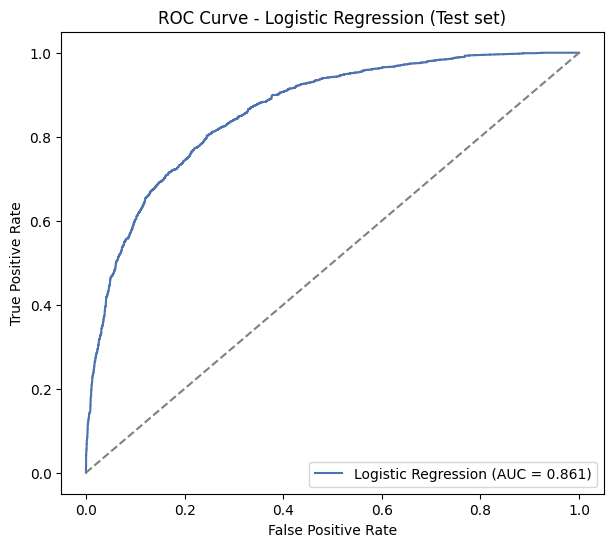

Test AUC: 0.8609


In [39]:
# ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, logit_proba_test)
auc_test = roc_auc_score(y_test, logit_proba_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_test:.3f})", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Test set)")
plt.legend(loc="lower right")
plt.show()

print("Test AUC:", round(auc_test, 4))

**Observation:**

The model has an **AUC of around 0.86**, which means it is able to distinguish between canceled and non-canceled bookings reasonably well.

The lower recall at the default 0.5 threshold does not necessarily mean that the model is poor. It may be possible to improve the identification of cancellations by changing the **classification threshold**.


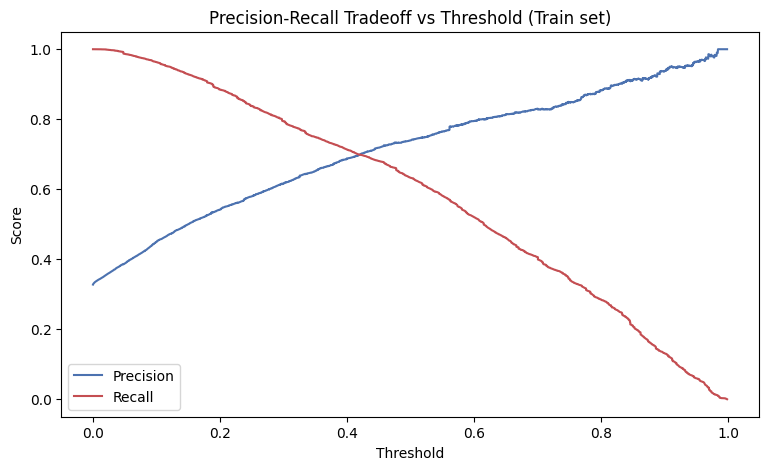

Selected threshold: 0.42


In [40]:
# Finding a better decision threshold by locating where precision and recall are balanced
precisions, recalls, thresholds = precision_recall_curve(y_train, logit_proba_train)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#4C72B0")
plt.plot(thresholds, recalls[:-1], label="Recall", color="#C44E52")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff vs Threshold (Train set)")
plt.legend()
plt.show()

# Optimal threshold: where precision and recall are closest (balanced)
diffs = np.abs(precisions[:-1] - recalls[:-1])
optimal_threshold = thresholds[np.argmin(diffs)]
print("Selected threshold:", round(optimal_threshold, 3))

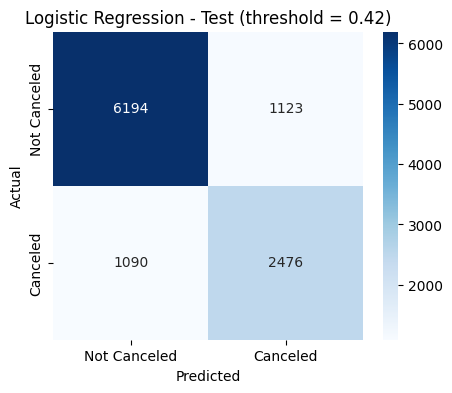

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,0.806593,0.632528,0.739460,0.681827
1,Logistic Regression (0.5 threshold),Test,0.802720,0.626192,0.732852,0.675336
2,Logistic Regression (optimal threshold),Train,0.802694,0.698882,0.698882,0.698882
3,Logistic Regression (optimal threshold),Test,0.796655,0.694335,0.687969,0.691137


In [41]:
# Re-classifying at the optimal threshold
logit_pred_train_opt = (logit_proba_train >= optimal_threshold).astype(int)
logit_pred_test_opt = (logit_proba_test >= optimal_threshold).astype(int)

results.append(get_metrics(y_train, logit_pred_train_opt, "Logistic Regression (optimal threshold)", "Train"))
results.append(get_metrics(y_test, logit_pred_test_opt, "Logistic Regression (optimal threshold)", "Test"))

plot_confusion_matrix(y_test, logit_pred_test_opt, f"Logistic Regression - Test (threshold = {optimal_threshold:.2f})")

pd.DataFrame(results)

**Observation:**

When the threshold is reduced from **0.5 to around 0.42**, the recall on the test data improves from **62.6% to 69.4%**. This means the model is able to identify more of the bookings that are actually canceled.

At the same time, precision decreases slightly from **73.3% to 68.8%**, while accuracy remains almost the same, changing from **80.3% to 79.7%**.

Since identifying more actual cancellations can be useful for the hotel, a threshold of around **0.42** can be considered a better balance between recall and precision for this analysis.


## Final Model Summary

In [42]:
logit_summary = pd.DataFrame(results)
logit_summary

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,0.806593,0.632528,0.739460,0.681827
1,Logistic Regression (0.5 threshold),Test,0.802720,0.626192,0.732852,0.675336
2,Logistic Regression (optimal threshold),Train,0.802694,0.698882,0.698882,0.698882
3,Logistic Regression (optimal threshold),Test,0.796655,0.694335,0.687969,0.691137


**Final Logistic Regression Model:**

* The final model has **19 statistically significant predictors** with p-values less than 0.05. The model has a **Pseudo R-squared of around 0.33** and a **test AUC of around 0.86**.

* At the selected threshold of around **0.42**, the model gives approximately **80% accuracy, 69% recall, 69% precision, and 69% F1-score** on the test data.

* The train and test results are fairly close to each other. This suggests that the model is performing consistently on both datasets and there is no major sign of overfitting.

* Some of the important factors associated with **lower cancellation** are being a **repeat guest**, requesting a **parking space**, and making **special requests**.

* Factors associated with **higher cancellation** include **longer lead time**, **higher room price**, and having **previous cancellations**.

Overall, the Logistic Regression model provides a good balance between prediction performance and interpretability.


## Building a Naive Bayes Model

In [43]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred_train = nb_model.predict(X_train)
nb_pred_test = nb_model.predict(X_test)

results.append(get_metrics(y_train, nb_pred_train, "Naive Bayes", "Train"))
results.append(get_metrics(y_test, nb_pred_test, "Naive Bayes", "Test"))

pd.DataFrame(results)

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,0.806593,0.632528,0.739460,0.681827
1,Logistic Regression (0.5 threshold),Test,0.802720,0.626192,0.732852,0.675336
2,Logistic Regression (optimal threshold),Train,0.802694,0.698882,0.698882,0.698882
3,Logistic Regression (optimal threshold),Test,0.796655,0.694335,0.687969,0.691137
4,Naive Bayes,Train,0.412610,0.964178,0.354316,0.518203
5,Naive Bayes,Test,0.409997,0.962984,0.353183,0.516818


## Model Performance Evaluation

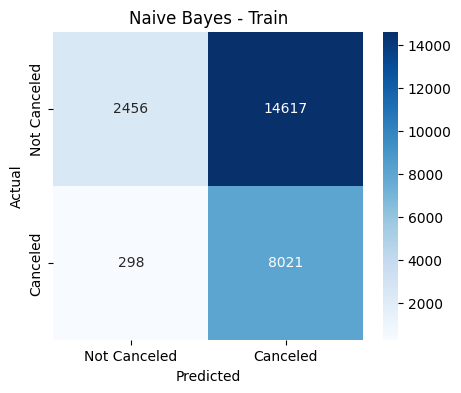

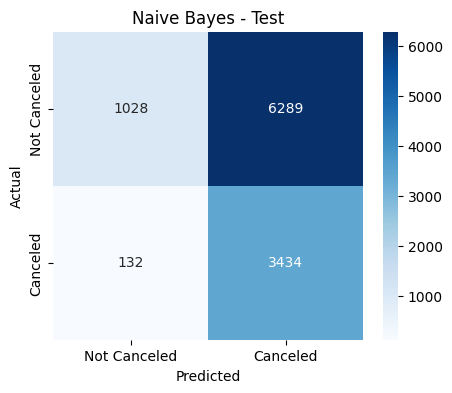

In [44]:
plot_confusion_matrix(y_train, nb_pred_train, "Naive Bayes - Train")
plot_confusion_matrix(y_test, nb_pred_test, "Naive Bayes - Test")

In [45]:
nb_proba_test = nb_model.predict_proba(X_test)[:, 1]
nb_auc_test = roc_auc_score(y_test, nb_proba_test)
print("Naive Bayes Test AUC:", round(nb_auc_test, 4))

Naive Bayes Test AUC: 0.7965


**Observation:**

The Naive Bayes model has a very high **recall of around 96%**, which means it is able to identify most of the bookings that are actually canceled.

However, its **precision is only around 35%**, and the overall **accuracy is around 41%**. This means that the model is predicting many bookings as canceled even when they are not. Its accuracy is also lower than the accuracy obtained by simply predicting the majority class.

The model has an **AUC of around 0.80**, which shows that it still has some ability to distinguish between canceled and non-canceled bookings.

Overall, Naive Bayes gives very high recall but poor precision and accuracy for this dataset. Therefore, it may not be the most suitable model for making the final predictions.


## Building SVM

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_linear = SVC(kernel="linear", random_state=1)
svm_linear.fit(X_train_scaled, y_train)

svm_rbf = SVC(kernel="rbf", random_state=1)
svm_rbf.fit(X_train_scaled, y_train)

print("Both SVM models trained.")

Both SVM models trained.


## Model Performance Evaluation

In [47]:
svm_linear_pred_train = svm_linear.predict(X_train_scaled)
svm_linear_pred_test = svm_linear.predict(X_test_scaled)

svm_rbf_pred_train = svm_rbf.predict(X_train_scaled)
svm_rbf_pred_test = svm_rbf.predict(X_test_scaled)

results.append(get_metrics(y_train, svm_linear_pred_train, "SVM (linear kernel)", "Train"))
results.append(get_metrics(y_test, svm_linear_pred_test, "SVM (linear kernel)", "Test"))
results.append(get_metrics(y_train, svm_rbf_pred_train, "SVM (RBF kernel)", "Train"))
results.append(get_metrics(y_test, svm_rbf_pred_test, "SVM (RBF kernel)", "Test"))

pd.DataFrame(results)

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,0.806593,0.632528,0.739460,0.681827
1,Logistic Regression (0.5 threshold),Test,0.802720,0.626192,0.732852,0.675336
2,Logistic Regression (optimal threshold),Train,0.802694,0.698882,0.698882,0.698882
3,Logistic Regression (optimal threshold),Test,0.796655,0.694335,0.687969,0.691137
4,Naive Bayes,Train,0.412610,0.964178,0.354316,0.518203
5,Naive Bayes,Test,0.409997,0.962984,0.353183,0.516818
6,SVM (linear kernel),Train,0.804663,0.615338,0.744149,0.673641
7,SVM (linear kernel),Test,0.801893,0.608525,0.740614,0.668103
8,SVM (RBF kernel),Train,0.845109,0.688424,0.810272,0.744395
9,SVM (RBF kernel),Test,0.834972,0.662647,0.799391,0.724624


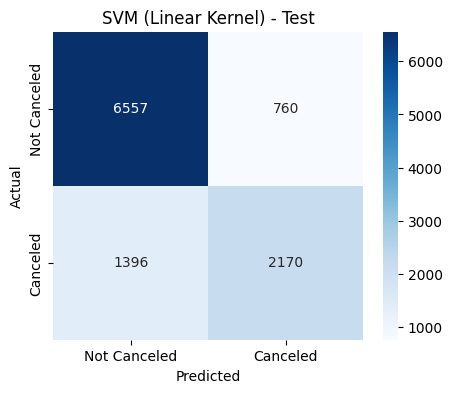

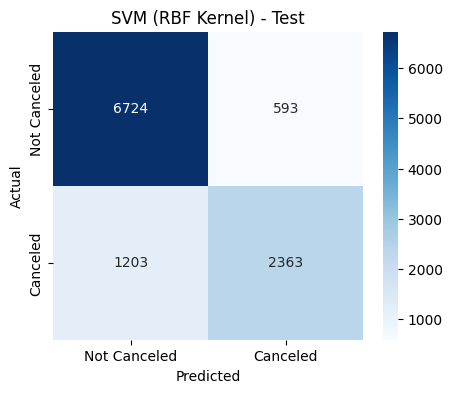

In [48]:
plot_confusion_matrix(y_test, svm_linear_pred_test, "SVM (Linear Kernel) - Test")
plot_confusion_matrix(y_test, svm_rbf_pred_test, "SVM (RBF Kernel) - Test")

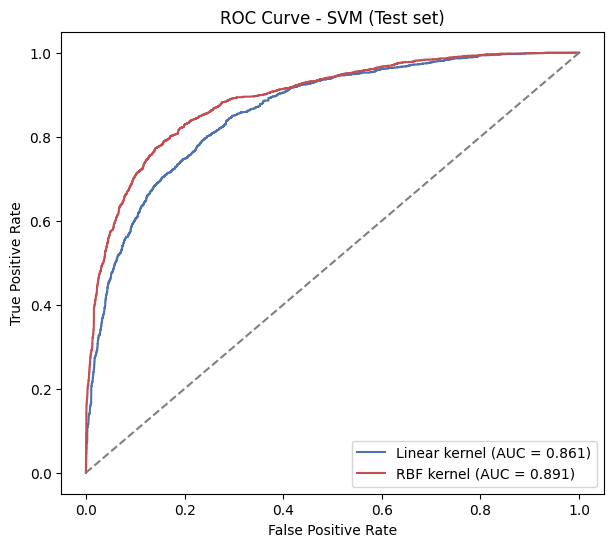

In [49]:
# ROC curves for both kernels (using the decision function as the score)
fpr_lin, tpr_lin, _ = roc_curve(y_test, svm_linear.decision_function(X_test_scaled))
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, svm_rbf.decision_function(X_test_scaled))
auc_lin = roc_auc_score(y_test, svm_linear.decision_function(X_test_scaled))
auc_rbf = roc_auc_score(y_test, svm_rbf.decision_function(X_test_scaled))

plt.figure(figsize=(7, 6))
plt.plot(fpr_lin, tpr_lin, label=f"Linear kernel (AUC = {auc_lin:.3f})", color="#4C72B0")
plt.plot(fpr_rbf, tpr_rbf, label=f"RBF kernel (AUC = {auc_rbf:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (Test set)")
plt.legend(loc="lower right")
plt.show()

**Observation:**

The **RBF kernel performs better than the linear kernel** for this dataset. The test accuracy is **83.5%** for RBF compared to **80.2%** for the linear kernel.

RBF also gives better results for the other metrics, with **66.3% recall, 79.9% precision, 72.5% F1-score, and 0.891 AUC**. The linear kernel gives **60.9% recall, 74.1% precision, 66.8% F1-score, and 0.861 AUC**.

This suggests that the relationship between the different booking variables and cancellation is not completely linear, and the RBF kernel is able to capture some of these patterns better.

The train and test results are also fairly close for both kernels, so there does not seem to be a major overfitting problem.


## Final Model Summary

In [50]:
svm_summary = pd.DataFrame(results)[pd.DataFrame(results)["Model"].str.contains("SVM")]
svm_summary

,Model,Data,Accuracy,Recall,Precision,F1
6,SVM (linear kernel),Train,0.804663,0.615338,0.744149,0.673641
7,SVM (linear kernel),Test,0.801893,0.608525,0.740614,0.668103
8,SVM (RBF kernel),Train,0.845109,0.688424,0.810272,0.744395
9,SVM (RBF kernel),Test,0.834972,0.662647,0.799391,0.724624


**Final SVM Model:**

The **RBF-kernel SVM** performs better than the linear SVM for this dataset. It gives a test accuracy of **83.5%**, precision of **79.9%**, and AUC of **0.891**, along with a recall of **66.3%**.

The main limitation of the RBF SVM is that it is harder to interpret compared to Logistic Regression. It does not provide simple coefficients that can directly explain which factors increase or decrease the cancellation risk.

Therefore, the RBF SVM is useful when the main goal is **predicting or scoring cancellation risk**, while Logistic Regression is more useful when we also want to understand the factors behind the prediction.


## Model Performance Comparison and Conclusions

In [51]:
final_comparison = pd.DataFrame(results)
for col in ["Accuracy", "Recall", "Precision", "F1"]:
    final_comparison[col] = (final_comparison[col] * 100).round(2)
final_comparison = final_comparison.reset_index(drop=True)
final_comparison

,Model,Data,Accuracy,Recall,Precision,F1
0,Logistic Regression (0.5 threshold),Train,80.66,63.25,73.95,68.18
1,Logistic Regression (0.5 threshold),Test,80.27,62.62,73.29,67.53
2,Logistic Regression (optimal threshold),Train,80.27,69.89,69.89,69.89
3,Logistic Regression (optimal threshold),Test,79.67,69.43,68.80,69.11
4,Naive Bayes,Train,41.26,96.42,35.43,51.82
5,Naive Bayes,Test,41.00,96.30,35.32,51.68
6,SVM (linear kernel),Train,80.47,61.53,74.41,67.36
7,SVM (linear kernel),Test,80.19,60.85,74.06,66.81
8,SVM (RBF kernel),Train,84.51,68.84,81.03,74.44
9,SVM (RBF kernel),Test,83.50,66.26,79.94,72.46


In [52]:
# Focusing on test-set performance for the final head-to-head comparison
test_comparison = final_comparison[final_comparison["Data"] == "Test"].drop(columns="Data").set_index("Model")
test_comparison.sort_values("F1", ascending=False)

,Accuracy,Recall,Precision,F1
Model,,,,
SVM (RBF kernel),83.50,66.26,79.94,72.46
Logistic Regression (optimal threshold),79.67,69.43,68.80,69.11
Logistic Regression (0.5 threshold),80.27,62.62,73.29,67.53
SVM (linear kernel),80.19,60.85,74.06,66.81
Naive Bayes,41.00,96.30,35.32,51.68


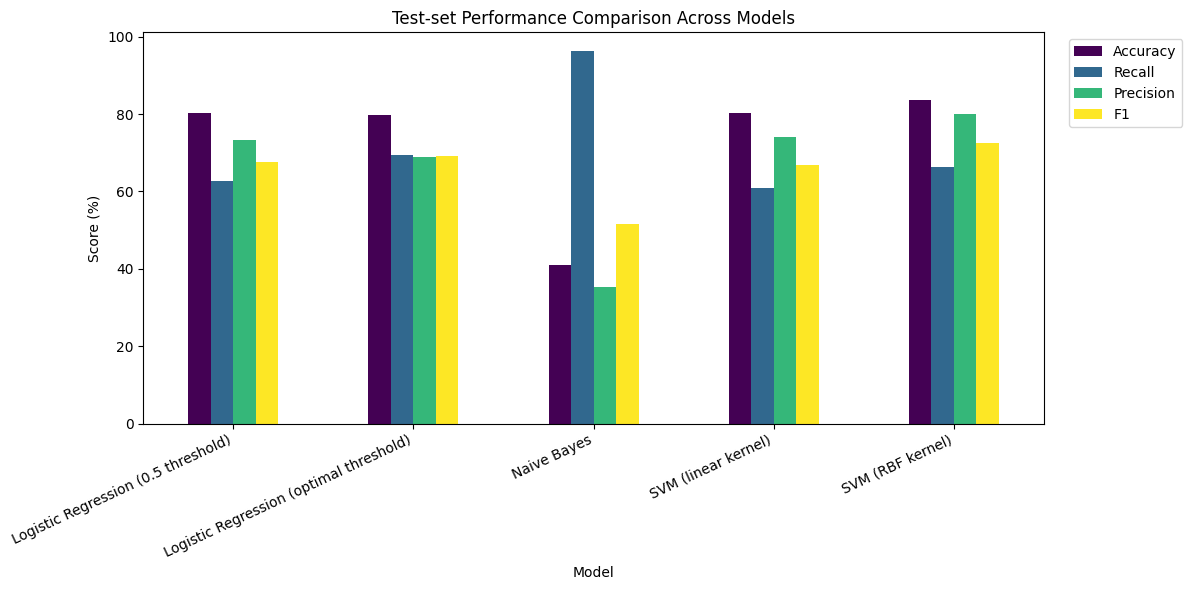

In [53]:
test_comparison[["Accuracy", "Recall", "Precision", "F1"]].plot(
    kind="bar", figsize=(12, 6), colormap="viridis"
)
plt.title("Test-set Performance Comparison Across Models")
plt.ylabel("Score (%)")
plt.xticks(rotation=25, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusions:**

* **Naive Bayes** performed the weakest overall. Its test accuracy was only around **41%**, which is much lower than the **67% majority-class baseline**. Although it had a very high recall of around **96%**, its precision was only around **35%**, meaning it predicted many bookings as canceled when they were actually not canceled. Therefore, it may not be very useful for practical use.

* **SVM with the RBF kernel** gave the best overall performance among the models tested. It achieved **83.5% test accuracy, 79.9% precision, 72.5% F1-score, and 0.891 AUC**, along with a recall of **66.3%**. The better performance compared to the linear SVM suggests that some non-linear relationships are present in the data.

* **Logistic Regression**, with the threshold adjusted to around **0.42**, achieved a recall of **69.4%**. Its main advantage is that the model is easier to understand because its coefficients and odds ratios can be used to identify the factors associated with booking cancellations. This makes it useful for understanding the business side of the problem.

* **Linear SVM** performed reasonably well but was slightly behind the RBF SVM. Its results also show that a linear relationship captures a large part of the information in the data, although the RBF kernel is able to capture some additional patterns.

**Recommendation:**

Based on the model results, the **RBF SVM can be used for predicting cancellation risk**, as it gives the highest overall accuracy, precision, F1-score and AUC among the models tested.

At the same time, **Logistic Regression can be used to understand the main factors related to cancellations**, such as lead time, room price, previous cancellations, repeat guests and special requests. This can help the hotel decide what actions to take for bookings that are likely to be canceled.

If the hotel wants to focus more on **identifying as many potential cancellations as possible**, the Logistic Regression model with the lower threshold of around **0.42** can also be considered because it gives a higher recall of **69.4%**.


## Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?
- What other recommedations would you suggest to the hotel?

### Key Insights

1. **Cancellations are a major issue:** Around **32.8% of all bookings are canceled**, which means roughly 1 out of every 3 bookings does not result in a stay. The highest number of cancellations is seen in **October, September and August**, which are also peak months. This can lead to more revenue loss because the hotel may have less time to sell the canceled rooms again.

2. **Lead time is an important factor:** The longer the time between booking and arrival, the higher the chance of cancellation. The model shows that cancellation odds increase by around **1.6% for every additional day of lead time**. The median lead time is also much higher for canceled bookings (**around 113 days**) compared to bookings that are honored (**around 43 days**).

3. **Repeat guests are much less likely to cancel:** Repeat guests have a cancellation rate of only around **1.7%**, compared to **33.6% for new guests**. This is a very large difference and shows that guest loyalty is strongly associated with lower cancellation rates.

4. **Special requests and other booking details are useful signals:** Guests who make **special requests, request parking, or select a meal plan** tend to cancel less often. These variables can therefore be useful indicators of how committed a guest is to the booking.

5. **Room price is also related to cancellations:** Higher room prices are associated with slightly higher cancellation odds. The **Online segment** also has a relatively high cancellation rate and the highest average room price, while **Corporate and Offline** bookings have lower cancellation rates.

6. **Cancellations increased in 2018:** Bookings made in **2018 have higher cancellation odds than those made in 2017**, even after considering other variables in the model. This is something the hotel should continue to monitor.

### Recommendations for Cancellation and Refund Policy

* **Use different cancellation policies based on lead time:** For bookings made far in advance, the hotel can consider asking for a partial non-refundable deposit or having a stricter cancellation period. This can be especially useful for bookings with **long lead time, high room price and Online booking**.

* **Contact high-risk customers before arrival:** The model's cancellation score can be used to identify bookings that have a higher chance of cancellation. The hotel could send these customers a confirmation reminder or a small offer, such as a **breakfast upgrade or early check-in**, around 2–3 weeks before arrival.

* **Encourage guests to add booking details:** Since special requests, meal plans and parking requests are associated with lower cancellation rates, the hotel could encourage guests to select these options during booking. However, this is only an association, so an **A/B test** would be needed to check whether encouraging these actions actually reduces cancellations.

* **Focus on repeat guests:** Since repeat guests have a much lower cancellation rate, the hotel can use **loyalty programs, discounts, points or upgrades** to encourage more guests to return.

* **Use cancellation risk when planning room availability:** Instead of using the same overbooking level for every date, the hotel can consider the predicted cancellation risk of upcoming bookings. This could be particularly useful during the **August–October period**, when demand and cancellations are both high.

* **Consider different policies for different market segments:** The hotel can study whether stricter cancellation terms are appropriate for the **Online segment**, while more flexible terms may be possible for segments with lower cancellation rates.

* **Offer early-booking discounts with stricter conditions:** For customers booking far in advance, the hotel could offer a small discount in return for a **non-refundable or stricter cancellation policy**. This may encourage customers to commit to the booking while still making the offer attractive.

* **Use the model as part of regular hotel operations:** The cancellation model can be used to regularly score upcoming bookings and identify high-risk reservations. These bookings can then be shown on a dashboard so that the operations team can take action before the arrival date.
